Customer Churn Prediction — Classification Analysis

Author: Cole Bennington
Project Type: Supervised Machine Learning (Binary Classification)
Tools: Python, Pandas, Scikit-learn, Matplotlib
Dataset: Telco Customer Churn (7,043 customers)

Project Objective

The objective of this project is to predict customer churn using classification models and identify the key factors influencing customer attrition. The goal is to provide actionable business recommendations to improve customer retention.

Business Problem

Customer churn directly impacts recurring revenue and customer lifetime value. By identifying high-risk customers and understanding the drivers of churn, businesses can implement targeted retention strategies to reduce revenue loss.

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_excel("Telco_customer_churn.xlsx")

# Preview data
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [3]:
# Convert Total Charges to numeric
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

# Check for missing values
df["Total Charges"].isnull().sum()

np.int64(11)

In [4]:
# Drop rows with missing Total Charges
df = df.dropna(subset=["Total Charges"])

# Confirm removal
df.shape

(7032, 33)

In [5]:
# Columns to drop
columns_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Score",
    "Churn Reason",
    "Churn Label"
]

df = df.drop(columns=columns_to_drop)

df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,5372
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,5340


In [6]:
# Define target
y = df["Churn Value"]

# Define features
X = df.drop("Churn Value", axis=1)

X.shape, y.shape

((7032, 20), (7032,))

In [7]:
# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded.shape

(7032, 31)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((5625, 31), (1407, 31))

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Initialize model
log_model = LogisticRegression(max_iter=1000)

# Train
log_model.fit(X_train, y_train)

# Predict
y_pred_log = log_model.predict(X_test)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log)
recall = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)

print("Logistic Regression Results:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Logistic Regression Results:
Accuracy: 0.806680881307747
Precision: 0.6473988439306358
Recall: 0.5989304812834224
F1 Score: 0.6222222222222222


c:\Users\coleb\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
conf_matrix = confusion_matrix(y_test, y_pred_log)
conf_matrix

array([[911, 122],
       [150, 224]])

In [11]:
y.mean()

np.float64(0.26578498293515357)

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create pipeline with scaling
log_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

# Train
log_pipeline.fit(X_train, y_train)

# Predict
y_pred_scaled = log_pipeline.predict(X_test)

# Evaluate
accuracy_s = accuracy_score(y_test, y_pred_scaled)
precision_s = precision_score(y_test, y_pred_scaled)
recall_s = recall_score(y_test, y_pred_scaled)
f1_s = f1_score(y_test, y_pred_scaled)

print("Scaled Logistic Regression Results:")
print("Accuracy:", accuracy_s)
print("Precision:", precision_s)
print("Recall:", recall_s)
print("F1 Score:", f1_s)

Scaled Logistic Regression Results:
Accuracy: 0.806680881307747
Precision: 0.6457142857142857
Recall: 0.6042780748663101
F1 Score: 0.6243093922651933


In [13]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results:")
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1 Score:", f1_rf)

Random Forest Results:
Accuracy: 0.7967306325515281
Precision: 0.6401273885350318
Recall: 0.5374331550802139
F1 Score: 0.5843023255813954


In [14]:
# Get predicted probabilities
y_probs = log_pipeline.predict_proba(X_test)[:, 1]

In [15]:
import numpy as np

# Custom threshold
threshold = 0.3

y_pred_custom = (y_probs >= threshold).astype(int)

# Evaluate
accuracy_c = accuracy_score(y_test, y_pred_custom)
precision_c = precision_score(y_test, y_pred_custom)
recall_c = recall_score(y_test, y_pred_custom)
f1_c = f1_score(y_test, y_pred_custom)

print("Logistic Regression (Threshold = 0.3)")
print("Accuracy:", accuracy_c)
print("Precision:", precision_c)
print("Recall:", recall_c)
print("F1 Score:", f1_c)

Logistic Regression (Threshold = 0.3)
Accuracy: 0.7484008528784648
Precision: 0.5183823529411765
Recall: 0.7540106951871658
F1 Score: 0.6143790849673203


In [16]:
confusion_matrix(y_test, y_pred_custom)

array([[771, 262],
       [ 92, 282]])

In [17]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 0.8429267333088301


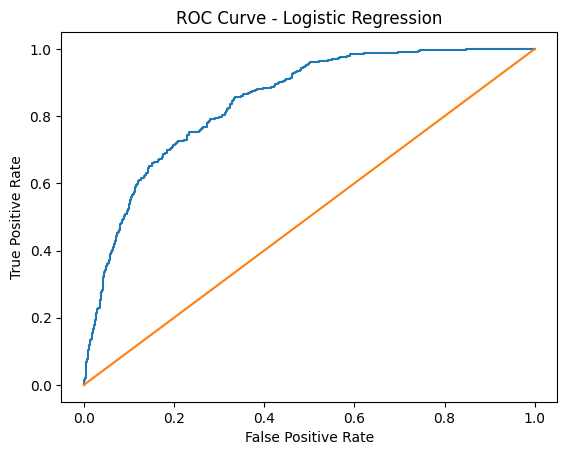

In [18]:
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.show()

In [20]:
feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": log_pipeline.named_steps['model'].coef_[0]
})

feature_importance = feature_importance.sort_values(by="Coefficient", ascending=False)

feature_importance.head(10)

,Feature,Coefficient
2,Total Charges,0.642945
11,Internet Service_Fiber optic,0.600893
22,Streaming TV_Yes,0.219999
10,Multiple Lines_Yes,0.200279
24,Streaming Movies_Yes,0.197788
29,Payment Method_Electronic check,0.179385
27,Paperless Billing_Yes,0.135540
6,Partner_Yes,0.119641
18,Device Protection_Yes,0.040198
9,Multiple Lines_No phone service,0.037235


In [21]:
feature_importance.sort_values(by="Coefficient").head(10)

,Feature,Coefficient
0,Tenure Months,-1.379455
7,Dependents_Yes,-0.691473
1,Monthly Charges,-0.626745
26,Contract_Two year,-0.590264
25,Contract_One year,-0.327669
14,Online Security_Yes,-0.144704
20,Tech Support_Yes,-0.137896
15,Online Backup_No internet service,-0.075245
17,Device Protection_No internet service,-0.075245
19,Tech Support_No internet service,-0.075245


Business Recommendations
Key Findings
Customer tenure is the strongest predictor of retention. Customers with longer tenure are significantly less likely to churn.
Contract-based customers (especially two-year contracts) churn at much lower rates compared to month-to-month customers.
Customers using fiber optic internet show elevated churn risk.
Customers paying via electronic check are more likely to churn.
Add-on services such as Tech Support and Online Security reduce churn probability.
Strategic Recommendations
Incentivize Long-Term Contracts
Offer discounts or perks to encourage customers to move from month-to-month to one- or two-year contracts.
Early Tenure Engagement Program
Since churn risk is highest early in the lifecycle, implement onboarding campaigns and proactive customer support within the first 6 months.
Review Fiber Optic Customer Experience
Conduct satisfaction analysis to identify pricing, service reliability, or expectation gaps among fiber optic customers.
Promote Value-Added Services
Bundle Tech Support and Online Security services into promotional packages to increase stickiness.
Target High-Risk Payment Segments
Analyze why electronic check users churn more frequently and consider incentives for switching to auto-pay methods.

Project Summary
Logistic Regression achieved an AUC of 0.84, indicating strong classification performance.
Tenure and contract length were the strongest predictors of reduced churn.
Fiber optic customers and electronic check users showed higher churn risk.
Threshold tuning improved recall for identifying high-risk customers.
The model provides actionable insight for targeted retention strategies.